# Part 2: Benchmarking Analysis 

In [6]:
# Load necessary packages

library(Seurat)
library(SeuratData)
library(SingleR)
library(scran)
library(ggplot2)
library(dplyr)
library(tidyr)
library(patchwork)

setwd('C:/Users/20815/Desktop/CMML2') #Your own environment

# ============================================
# Load and Process All Datasets
# ============================================

# Original reference
data("pbmc3k")
pbmc3k_raw <- UpdateSeuratObject(pbmc3k)

# Load all 9 downsampled datasets
all_datasets <- list()
dc_props <- c("10pct", "1pct", "01pct")
depths <- c("100pct", "50pct", "25pct")

for (dc in dc_props) {
  for (depth in depths) {
    name <- paste0("DC_", dc, "_depth_", depth)
    file_path <- file.path("simulated_data_downsampled", paste0(name, ".rds"))
    
    if (file.exists(file_path)) {
      all_datasets[[name]] <- readRDS(file_path)
    }
  }
}

# Processing function
process_to_seurat <- function(data_obj, dataset_name, is_sce = TRUE) {
  
  if (is_sce) {
    seurat_obj <- CreateSeuratObject(
      counts = counts(data_obj), 
      project = dataset_name,
      meta.data = as.data.frame(colData(data_obj))
    )
  } else {
    seurat_obj <- data_obj
  }
  
  seurat_obj <- NormalizeData(seurat_obj)
  seurat_obj <- FindVariableFeatures(seurat_obj, nfeatures = 1500)
  seurat_obj <- ScaleData(seurat_obj)
  seurat_obj <- RunPCA(seurat_obj, npcs = 30, verbose = FALSE)
  seurat_obj <- FindNeighbors(seurat_obj, dims = 1:20)
  seurat_obj <- FindClusters(seurat_obj, resolution = 0.5, verbose = FALSE)
  seurat_obj <- RunUMAP(seurat_obj, dims = 1:20, verbose = FALSE)
  
  # Standardize cell type column
  if ("cell_type" %in% colnames(seurat_obj[[]])) {
    seurat_obj$cell_type <- as.character(seurat_obj$cell_type)
  }
  if ("seurat_annotations" %in% colnames(seurat_obj[[]])) {
    seurat_obj$seurat_annotations <- as.character(seurat_obj$seurat_annotations)
  }
  
  return(seurat_obj)
}

# Process all datasets
seurat_original <- process_to_seurat(pbmc3k_raw, "Original", is_sce = FALSE)

seurat_objects <- list()
seurat_objects[["Original"]] <- seurat_original

for (name in names(all_datasets)) {
  if (grepl("10pct", name)) {
    dc_label <- "10% DC"
  } else if (grepl("_1pct_", name)) { 
    dc_label <- "1% DC"
  } else if (grepl("01pct", name)) {
    dc_label <- "0.1% DC"
  }
  
  if (grepl("100pct", name)) {
    depth_label <- "100%"
  } else if (grepl("50pct", name)) {
    depth_label <- "50%"
  } else {
    depth_label <- "25%"
  }
  
  full_name <- paste0(dc_label, "_", depth_label)
  seurat_objects[[full_name]] <- process_to_seurat(all_datasets[[name]], full_name)
  cat(sprintf("✓ Processed: %s\n", full_name))
}

Validating object structure

Updating object slots

Ensuring keys are in the proper structure

Warning message:
"Assay RNA changing from Assay to Assay"
Ensuring keys are in the proper structure

Ensuring feature names don't have underscores or pipes

Updating slots in RNA

Validating object structure for Assay 'RNA'

Object representation is consistent with the most current Seurat version

Centering and scaling data matrix

Computing nearest neighbor graph

Computing SNN

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Computing nearest neighbor graph

Computing SNN



✓ Processed: 10% DC_100%


Warning message:
"Data is of class matrix. Coercing to dgCMatrix."
Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Computing nearest neighbor graph

Computing SNN



✓ Processed: 10% DC_50%


Warning message:
"Data is of class matrix. Coercing to dgCMatrix."
Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Computing nearest neighbor graph

Computing SNN



...

✓ Processed: 0.1% DC_100%


Warning message:
"Data is of class matrix. Coercing to dgCMatrix."
Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Computing nearest neighbor graph

Computing SNN



✓ Processed: 0.1% DC_50%


Warning message:
"Data is of class matrix. Coercing to dgCMatrix."
Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Computing nearest neighbor graph

Computing SNN



✓ Processed: 0.1% DC_25%


In [7]:

# ============================================
# Tool 1: Seurat Clustering 
# ============================================

evaluate_clustering <- function(seurat_obj, dataset_name) {
  
  if ("cell_type" %in% colnames(seurat_obj[[]])) {
    true_label <- seurat_obj$cell_type
  } else {
    true_label <- seurat_obj$seurat_annotations
  }
  true_label <- as.character(true_label)
  true_label[is.na(true_label)] <- "Unknown"
  
  cluster_label <- seurat_obj$seurat_clusters
  
  # Calculate DC counts in each cluster
  cluster_dc_counts <- tapply(true_label == "DC", cluster_label, sum)
  total_dc <- sum(true_label == "DC")
  
  if (total_dc == 0) {
    return(data.frame(
      Tool = "Seurat",
      Dataset = dataset_name,
      Detection_Rate = 0,
      FPR = 0
    ))
  }
  
  # Find cluster with most DC
  best_cluster <- which.max(cluster_dc_counts)
  detected_dc <- cluster_dc_counts[best_cluster]
  cluster_size <- sum(cluster_label == names(best_cluster))
  
  detection_rate <- detected_dc / total_dc
  
  # Caluculate False Positive Rate
  fp <- cluster_size - detected_dc
  total_non_dc <- sum(true_label != "DC")
  fpr <- ifelse(total_non_dc > 0, fp / total_non_dc, 0)
  
  return(data.frame(
    Tool = "Seurat",
    Dataset = dataset_name,
    Detection_Rate = detection_rate,
    FPR = fpr
  ))
}

cat("\n=== Tool 1: Seurat Clustering ===\n")
seurat_results <- data.frame()
for (name in names(seurat_objects)) {
  result <- evaluate_clustering(seurat_objects[[name]], name)
  seurat_results <- rbind(seurat_results, result)
  cat(sprintf("  %s: Detection Rate = %.3f, FPR = %.4f\n", 
              name, result$Detection_Rate, result$FPR))
}


=== Tool 1: Seurat Clustering ===


  Original: Detection Rate = 0.938, FPR = 0.0011
  10% DC_100%: Detection Rate = 0.987, FPR = 0.0000
  10% DC_50%: Detection Rate = 0.983, FPR = 0.0000
  10% DC_25%: Detection Rate = 0.977, FPR = 0.0000
  1% DC_100%: Detection Rate = 0.800, FPR = 0.0549
  1% DC_50%: Detection Rate = 0.733, FPR = 0.0522
  1% DC_25%: Detection Rate = 0.733, FPR = 0.1111
  0.1% DC_100%: Detection Rate = 0.667, FPR = 0.0854
  0.1% DC_50%: Detection Rate = 1.000, FPR = 0.1398
  0.1% DC_25%: Detection Rate = 0.667, FPR = 0.1295


In [8]:

# ============================================
# Tool 2: SingleR 
# ============================================

run_singler <- function(seurat_obj, dataset_name, ref_seurat, ref_labels) {
  
  test_expr <- GetAssayData(seurat_obj, assay = "RNA", layer = "data")
  ref_expr <- GetAssayData(ref_seurat, assay = "RNA", layer = "data")
  
  common_genes <- intersect(rownames(test_expr), rownames(ref_expr))
  test_expr <- test_expr[common_genes, ]
  ref_expr <- ref_expr[common_genes, ]
  
  suppressWarnings({
    singler_results <- SingleR(
      test = test_expr,
      ref = ref_expr,
      labels = ref_labels,
      method = "single",
      fine.tune = TRUE
    )
  })
  
  predicted_labels <- singler_results$labels
  
  if ("cell_type" %in% colnames(seurat_obj[[]])) {
    true_labels <- seurat_obj$cell_type
  } else {
    true_labels <- seurat_obj$seurat_annotations
  }
  true_labels <- as.character(true_labels)
  true_labels[is.na(true_labels)] <- "Unknown"
  
  # Calculate related index
  dc_true <- which(true_labels == "DC")
  dc_pred <- which(predicted_labels == "DC")
  
  tp <- length(intersect(dc_true, dc_pred))
  fp <- length(setdiff(dc_pred, dc_true))
  fn <- length(setdiff(dc_true, dc_pred))
  tn <- sum(true_labels != "DC") - fp
  
  recall <- ifelse(length(dc_true) > 0, tp / length(dc_true), 0)
  fpr <- ifelse(tn + fp > 0, fp / (tn + fp), 0)
  
  return(data.frame(
    Tool = "SingleR",
    Dataset = dataset_name,
    Detection_Rate = recall,
    FPR = fpr
  ))
}

cat("\n=== Tool 2: SingleR ===\n")

reference_seurat <- seurat_original
reference_labels <- as.character(reference_seurat$seurat_annotations)
reference_labels[is.na(reference_labels)] <- "Unknown"

singler_results <- data.frame()
for (name in names(seurat_objects)) {
  result <- run_singler(seurat_objects[[name]], name, reference_seurat, reference_labels)
  singler_results <- rbind(singler_results, result)
  cat(sprintf("  %s: Detection Rate = %.3f, FPR = %.4f\n", 
              name, result$Detection_Rate, result$FPR))
}



=== Tool 2: SingleR ===


  Original: Detection Rate = 0.969, FPR = 0.0840
  10% DC_100%: Detection Rate = 0.997, FPR = 0.0804
  10% DC_50%: Detection Rate = 0.987, FPR = 0.0778
  10% DC_25%: Detection Rate = 0.960, FPR = 0.0785
  1% DC_100%: Detection Rate = 1.000, FPR = 0.0896
  1% DC_50%: Detection Rate = 1.000, FPR = 0.0825
  1% DC_25%: Detection Rate = 0.967, FPR = 0.0717
  0.1% DC_100%: Detection Rate = 1.000, FPR = 0.0878
  0.1% DC_50%: Detection Rate = 1.000, FPR = 0.0791
  0.1% DC_25%: Detection Rate = 1.000, FPR = 0.0821


In [9]:

# ============================================
# 4. Tool 3: scran 
# ============================================

# DC markers based on known literature
known_dc_markers <- c("CD1C", "FCER1A", "CST3", "HLA-DRA", "CD74", "HLA-DPB1")

run_scran <- function(seurat_obj, dataset_name, markers) {
  
  sce <- as.SingleCellExperiment(seurat_obj)
  
  if ("cell_type" %in% colnames(colData(sce))) {
    cell_type <- colData(sce)$cell_type
  } else {
    cell_type <- colData(sce)$seurat_annotations
  }
  cell_type <- as.character(cell_type)
  cell_type[is.na(cell_type)] <- "Unknown"
  
  total_dc <- sum(cell_type == "DC")
  
  if (total_dc == 0) {
    return(data.frame(
      Tool = "scran",
      Dataset = dataset_name,
      Top10_Recovery_Rate = 0,
      Top20_Recovery_Rate = 0
    ))
  }
  
  sce$group <- ifelse(cell_type == "DC", "DC", "Others")
  
  result <- tryCatch({
    de_results <- findMarkers(sce, groups = sce$group, pval.type = "any")
    
    if ("DC" %in% names(de_results)) {
      de_df <- as.data.frame(de_results$DC)
      de_df$gene <- rownames(de_df)
      de_df <- de_df[order(de_df$p.value), ]
      
      top10_genes <- head(de_df$gene, 10)
      top20_genes <- head(de_df$gene, 20)
      
      # Calculate recover rate
      markers_in_top10 <- sum(markers %in% top10_genes)
      markers_in_top20 <- sum(markers %in% top20_genes)
      
      recovery_top10 <- markers_in_top10 / length(markers)
      recovery_top20 <- markers_in_top20 / length(markers)
      
      return(data.frame(
        Tool = "scran",
        Dataset = dataset_name,
        Top10_Recovery_Rate = recovery_top10,
        Top20_Recovery_Rate = recovery_top20
      ))
    } else {
      return(data.frame(
        Tool = "scran",
        Dataset = dataset_name,
        Top10_Recovery_Rate = 0,
        Top20_Recovery_Rate = 0
      ))
    }
  }, error = function(e) {
    return(data.frame(
      Tool = "scran",
      Dataset = dataset_name,
      Top10_Recovery_Rate = 0,
      Top20_Recovery_Rate = 0
    ))
  })
  
  return(result)
}

cat("\n=== Tool 3: scran ===\n")
scran_results <- data.frame()
for (name in names(seurat_objects)) {
  result <- run_scran(seurat_objects[[name]], name, known_dc_markers)
  scran_results <- rbind(scran_results, result)
  cat(sprintf("  %s: Top10 Recovery = %.3f, Top20 Recovery = %.3f\n", 
              name, result$Top10_Recovery_Rate, result$Top20_Recovery_Rate))
}


=== Tool 3: scran ===


  Original: Top10 Recovery = 0.000, Top20 Recovery = 0.000
  10% DC_100%: Top10 Recovery = 0.667, Top20 Recovery = 0.667
  10% DC_50%: Top10 Recovery = 0.667, Top20 Recovery = 0.667
  10% DC_25%: Top10 Recovery = 0.667, Top20 Recovery = 0.667
  1% DC_100%: Top10 Recovery = 0.000, Top20 Recovery = 0.000
  1% DC_50%: Top10 Recovery = 0.000, Top20 Recovery = 0.000
  1% DC_25%: Top10 Recovery = 0.000, Top20 Recovery = 0.167
  0.1% DC_100%: Top10 Recovery = 0.000, Top20 Recovery = 0.000
  0.1% DC_50%: Top10 Recovery = 0.000, Top20 Recovery = 0.000
  0.1% DC_25%: Top10 Recovery = 0.000, Top20 Recovery = 0.000


In [ ]:
# ============================================
# 5. Save Results
# ============================================

write.csv(seurat_results, "Benchmark_Seurat.csv", row.names = FALSE)
write.csv(singler_results, "Benchmark_SingleR.csv", row.names = FALSE)
write.csv(scran_results, "Benchmark_scran.csv", row.names = FALSE)

In [10]:
# ============================================
# Figure 2: Benchmarking Visualization
# ============================================

library(ggplot2)
library(dplyr)
library(tidyr)
library(RColorBrewer)

# Define condition labels
dc_levels <- c("10% DC", "1% DC", "0.1% DC")
depth_levels <- c("100%", "50%", "25%")
method_levels <- c("Seurat", "SingleR", "scran")

# Build detection rate matrix (Seurat + SingleR only, scran uses different metric)
detection_data <- seurat_results %>%
  bind_rows(singler_results) %>%
  filter(Dataset != "Original") %>%
  mutate(
    DC_Prop = factor(gsub("_.*", "", Dataset), levels = dc_levels),
    Depth = factor(gsub(".*_", "", Dataset), levels = depth_levels),
    Condition = paste(DC_Prop, Depth, sep = "\n")
  )

# Build FPR matrix
fpr_data <- seurat_results %>%
  bind_rows(singler_results) %>%
  filter(Dataset != "Original") %>%
  mutate(
    DC_Prop = factor(gsub("_.*", "", Dataset), levels = dc_levels),
    Depth = factor(gsub(".*_", "", Dataset), levels = depth_levels),
    Condition = paste(DC_Prop, Depth, sep = "\n")
  )

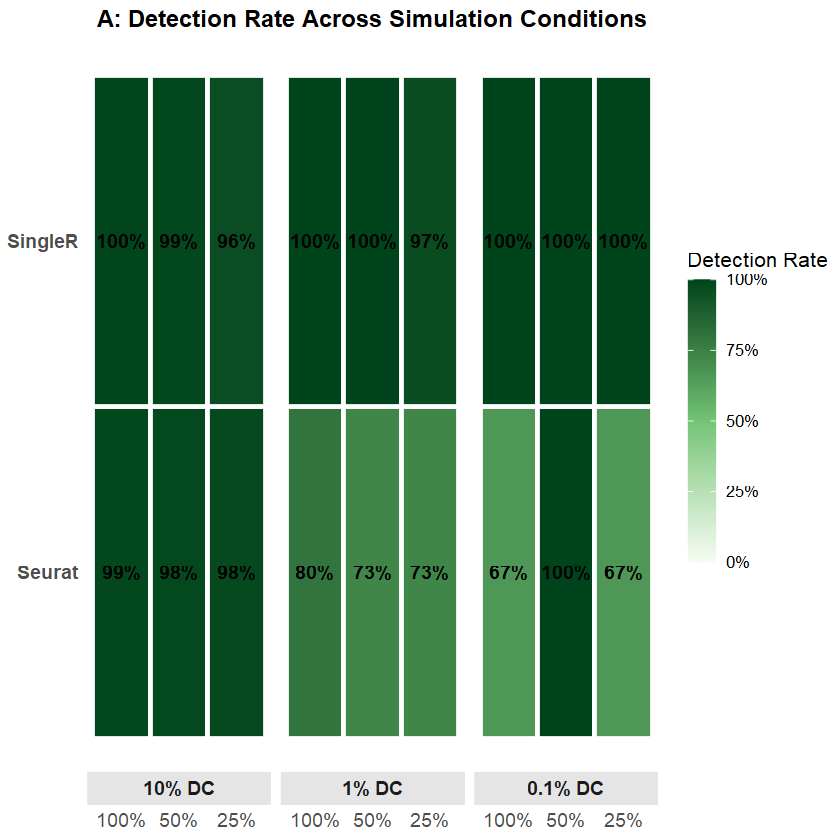

In [11]:

# ============================================
# Panel A: Detection Rate Heatmap 
# ============================================

p_heatmap_detection <- ggplot(detection_data, 
                              aes(x = Depth, y = Tool, fill = Detection_Rate)) +
  geom_tile(color = "white", linewidth = 1) +
  geom_text(aes(label = scales::percent(Detection_Rate, accuracy = 1)), 
            color = "black", size = 4, fontface = "bold") +
  facet_grid(~DC_Prop, switch = "x") +
  scale_fill_gradient2(
    low = "#F7FCF5", 
    mid = "#74C476", 
    high = "#00441B",
    midpoint = 0.5, 
    limits = c(0, 1),
    labels = scales::percent,
    name = "Detection Rate"
  ) +
  labs(
    title = "A: Detection Rate Across Simulation Conditions",
    x = NULL,
    y = NULL
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 14),
    plot.subtitle = element_text(hjust = 0.5, size = 10, color = "gray30"),
    panel.grid = element_blank(),
    strip.background = element_rect(fill = "gray90", linetype = "blank"),
    strip.text = element_text(face = "bold", size = 11),
    axis.text.x = element_text(size = 11),
    axis.text.y = element_text(face = "bold", size = 11),
    legend.position = "right",
    legend.key.width = unit(0.6, "cm"),
    legend.key.height = unit(1.2, "cm")
  )

print(p_heatmap_detection)

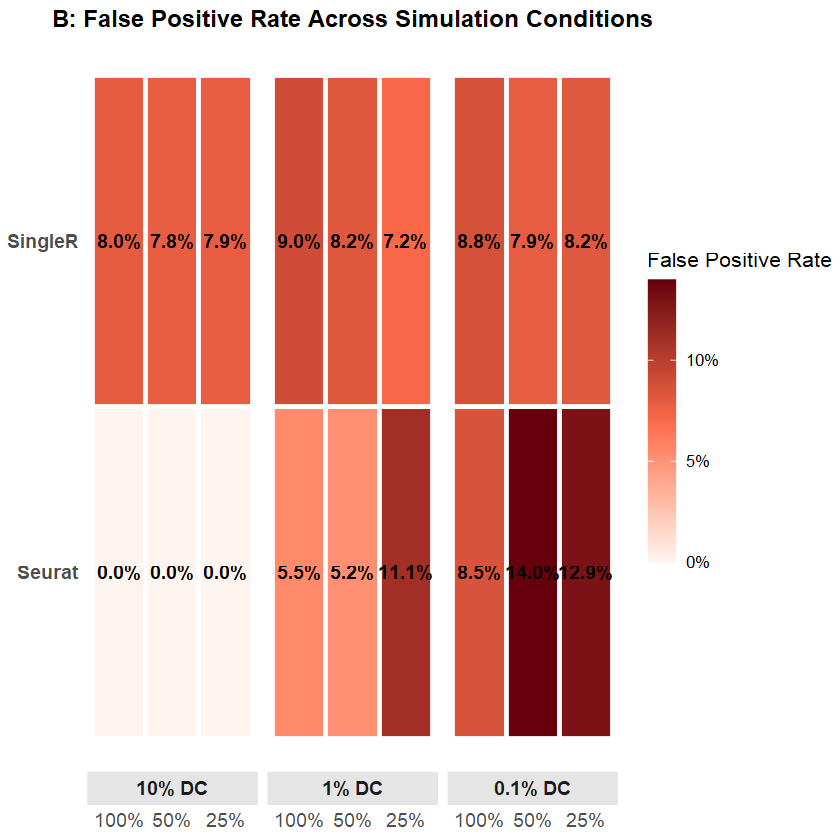

In [12]:

# ============================================
# Panel B: False Positive Rate Heatmap
# ============================================

# Find max FPR for consistent scale
max_fpr <- max(fpr_data$FPR, na.rm = TRUE)

p_heatmap_fpr <- ggplot(fpr_data, 
                        aes(x = Depth, y = Tool, fill = FPR)) +
  geom_tile(color = "white", linewidth = 1) +
  geom_text(aes(label = scales::percent(FPR, accuracy = 0.1)), 
            color = "black", size = 4, fontface = "bold") +
  facet_grid(~DC_Prop, switch = "x") +
  scale_fill_gradient2(
    low = "#FFF5F0", 
    mid = "#FB6A4A", 
    high = "#67000D",
    midpoint = max_fpr / 2, 
    limits = c(0, max_fpr),
    labels = scales::percent,
    name = "False Positive Rate"
  ) +
  labs(
    title = "B: False Positive Rate Across Simulation Conditions",
    x = NULL,
    y = NULL
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 14),
    plot.subtitle = element_text(hjust = 0.5, size = 10, color = "gray30"),
    panel.grid = element_blank(),
    strip.background = element_rect(fill = "gray90", linetype = "blank"),
    strip.text = element_text(face = "bold", size = 11),
    axis.text.x = element_text(size = 11),
    axis.text.y = element_text(face = "bold", size = 11),
    legend.position = "right",
    legend.key.width = unit(0.6, "cm"),
    legend.key.height = unit(1.2, "cm")
  )

print(p_heatmap_fpr)

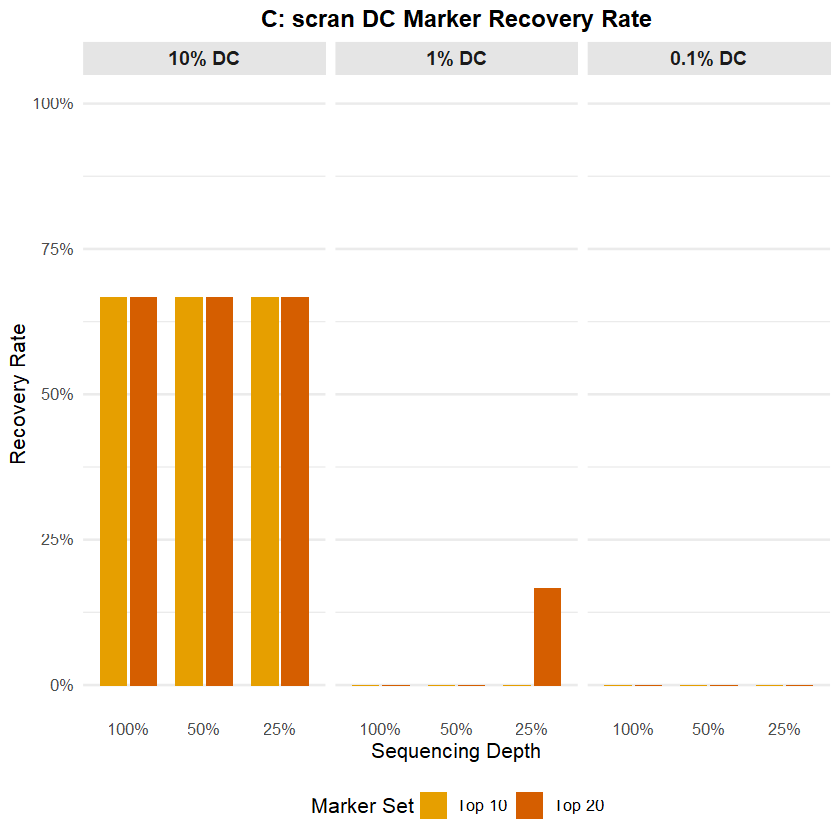

In [13]:


# ============================================
# Panel C: scran Marker Recovery Rate
# ============================================

# Prepare scran data
scran_results$DC_Proportion <- factor(
  gsub("_.*", "", scran_results$Dataset),
  levels = c("10% DC", "1% DC", "0.1% DC")
)
scran_results$Depth <- factor(
  gsub(".*_", "", scran_results$Dataset),
  levels = c("100%", "50%", "25%")
)

# Filter out Original (no depth label)
scran_plot_data <- scran_results %>%
  filter(DC_Proportion != "Original") %>%
  select(DC_Proportion, Depth, Top10_Recovery_Rate, Top20_Recovery_Rate) %>%
  pivot_longer(
    cols = c(Top10_Recovery_Rate, Top20_Recovery_Rate),
    names_to = "Marker_Set",
    values_to = "Recovery_Rate"
  ) %>%
  mutate(
    Marker_Set = recode(Marker_Set,
                        "Top10_Recovery_Rate" = "Top 10",
                        "Top20_Recovery_Rate" = "Top 20")
  )

p_bar_scran <- ggplot(scran_plot_data, 
                      aes(x = Depth, y = Recovery_Rate, fill = Marker_Set)) +
  geom_bar(stat = "identity", position = position_dodge(0.8), width = 0.7) +
  facet_wrap(~DC_Proportion, nrow = 1) +
  scale_fill_manual(values = c("Top 10" = "#E69F00", "Top 20" = "#D55E00")) +
  scale_y_continuous(labels = scales::percent, limits = c(0, 1), breaks = seq(0, 1, 0.25)) +
  labs(
    title = "C: scran DC Marker Recovery Rate",
    x = "Sequencing Depth",
    y = "Recovery Rate",
    fill = "Marker Set"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 14),
    plot.subtitle = element_text(hjust = 0.5, size = 10, color = "gray30"),
    panel.grid.major.x = element_blank(),
    legend.position = "bottom",
    strip.background = element_rect(fill = "gray90", linetype = "blank"),
    strip.text = element_text(face = "bold", size = 11)
  )

print(p_bar_scran)